In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import time

In [2]:
c=2.998*10**8 #in m/s

#in natural units:
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
f=28 #coupling strength

#in eV
w_minus = 55*10**-3
w_plus = 20*10**-3
m_Si_nucleus = 2.616e10
proton_mass= 938.272e6

dm_density = 0.3e9 #eV/cm^3, plus minus 0.1
target_density = 1.307e33 #eV/cm^3 from silicon density of 2329.6 kg/m3

#in 1/eV
a_Si = 2*np.pi/(2.28*1000) #Silicon lattice constant
a0 = 2.68e-4 #Bohr radius

# Structure Factor

The equation for the Structure Factor is as follows:
\begin{aligned}
    S(q,\omega) &= \sum_{\ell,\ell'} |f|^2 C_{\ell, \ell'} \\
    &= 2|f|^2 (C_{\ell=\ell'}+C_{\ell \neq \ell'})
\end{aligned}
The diagonal term is $$ C_{\boldsymbol{\ell}d} = \frac{1}{V} e^{-2W_d(\boldsymbol{q})} \sum_{n=0} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$ and the off-diagonal is $$C_{\boldsymbol{\ell '}\boldsymbol{\ell} d}=\frac{1}{V}e^{i\boldsymbol{q}\cdot(\boldsymbol{l}-\boldsymbol{\ell'})} e^{-2W_d(\boldsymbol{q})} \sum_{n=0}^{\omega/\omega_+} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi(-1)^{n-j}}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$

The function $W_d(q)$ is the Debye-Waller factor: $W_d(q)=\frac{q^2}{8m_d}(\frac{1}{\omega_1}+\frac{1}{\omega_2})$. When you integrate with $\omega$, the delta function gets removed, leaving a sum based on n and j for set values of $\omega_{n,j}$



In [3]:
"""
The Debye-Waller function for a two-site lattice
@params 
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
"""
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [4]:
"""
The diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
"""
def diagonal_C_true(q, m, w1,w2, n, j, V=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [5]:
"""
The off-diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
"""
def offDiagonal_C_true(q, m, w1,w2, n, j, V=a_Si, a=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*a)
    return c

In [6]:
"""
Structure Factor for one n and j pair, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n_j(q,m, w1, w2, n, j, V, a, A=f):
    return 2*A**2*(diagonal_C_true(q, m, w1, w2, n, j, V)
                      +offDiagonal_C_true(q, m, w1, w2, n, j, V, a))

In [7]:
"""
Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n(q, m, w1,w2, n, V, a, A=f):
    return sum([2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)
                        +offDiagonal_C_true(q, m, w1,w2, n, j, V, a)) for j in range(n+1)] )

In [8]:
"""
Diagonal Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    A: coupling strength
"""
def StructureFactor_diag(q, m, w1,w2, n, V, A):
    return sum([2*A**2* diagonal_C_true(q, m, w1,w2, n, j, V) for j in range(n+1)] )

In [9]:
#Calculate the structure factor integrated wrt omega for first 4 phonon numbers
q_range = 10**np.linspace(-1, np.log10(300), 3000) #keV
S_int_w = [[StructureFactor_n(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, a_Si, 1) for q in q_range] 
           for n in range(1,5)] #structure factor
S_int_diag= [[StructureFactor_diag(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, 1) for q in q_range] 
            for n in range(1,5)] #diagonal portion for reference

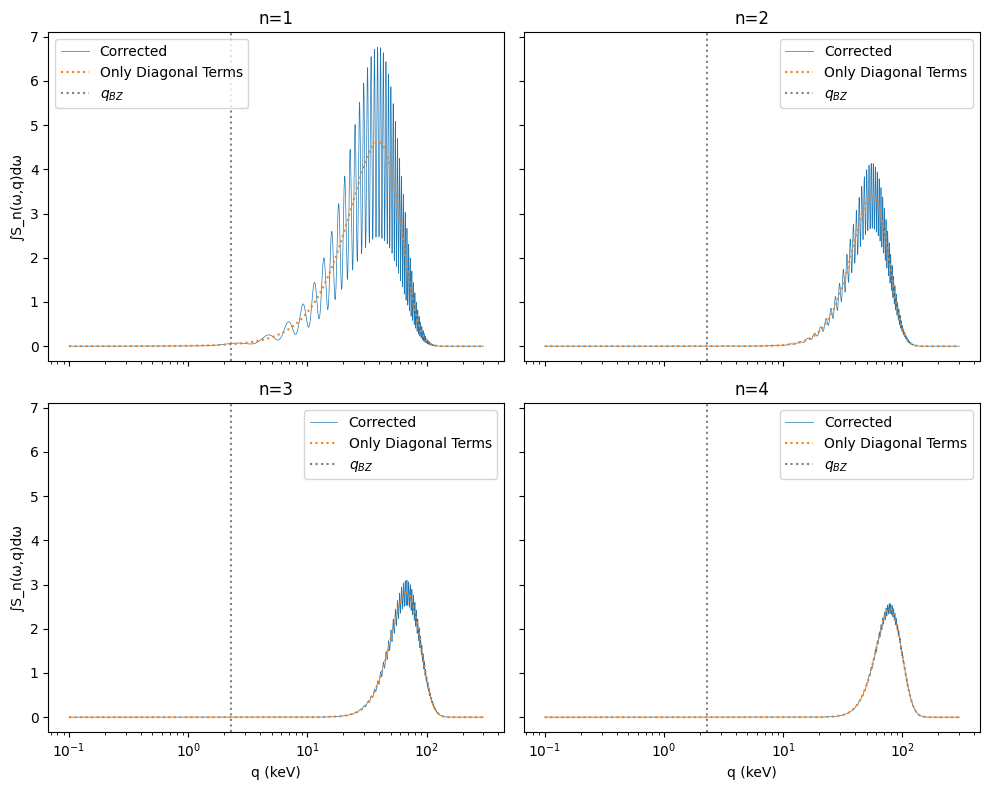

In [10]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(10, 8))
for n in range(4):
    axs[int(n/2), n%2].plot(q_range, S_int_w[n], linewidth=0.5, label = "Corrected")
    axs[int(n/2), n%2].plot(q_range, S_int_diag[n], linewidth=1.5, linestyle = ":", label="Only Diagonal Terms")
    axs[int((n)/2), n%2].set_xscale('log')
    axs[int((n)/2), n%2].set_title("n="+str(n+1))
    axs[int((n)/2), n%2].axvline(2.28, color="gray", linestyle=":", label=r"$q_{BZ}$")
    axs[int((n)/2), n%2].legend()
for ax in axs.flat:
    ax.set(xlabel='q (keV)', ylabel='∫S_n(ω,q)dω')
for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()
plt.show()

We can also make a color graph that shows the structure factor as a function of both energy and momentum transfer

In [11]:
"""
Find the possible combinations of n and j that give energies lower or equal to the maximum energy transfer
@params:
    omega: energy transfer from dark matter to crystal
    w1, w2: energy levels of the element
@returns:
    a list of paired principle phonon numbers and phonon modes
"""
def get_possible_n_j(omega, w1 = w_plus,w2=w_minus): 
    maxN = int(omega/w1)
    pairs = [(n, j) for n in range(1,maxN + 1) for j in range(n + 1)]
    pairs_array = np.array(pairs)
    n_values = pairs_array[:, 0]
    j_values = pairs_array[:, 1]
    condition = (j_values * w1 + (n_values - j_values) * w2) <= omega
    filtered_pairs = pairs_array[condition]
    return filtered_pairs

"""
Find all energies from the n,j pair
@params:
    n_j_pairs: a list of paired principle phonon numbers and phonon modes
    w1, w2: energy levels of the element
@ returns:
    List of all possible energies
"""
def get_possible_omega(n_j_pairs, w1 = w_plus,w2=w_minus):
    n_values = n_j_pairs[:, 0]
    j_values = n_j_pairs[:, 1]
    return j_values * w1 + (n_values - j_values) * w2

"""
Removes degenerate energies
@params:
    omega_list: list of energies
    s_list: list of structure factors
@returns:
    List of unique energies
    Corresponding list of structure factors
"""
def remove_degeneracy(omega_list, s_list):
    unique_omega = np.unique(omega_list)
    unique_s = []
    for val in unique_omega:
        indices = np.where(omega_list == val)[0]
        unique_s.append(np.sum(s_list[indices], axis=0))
    return unique_omega, np.array(unique_s)

In [17]:
#We get all the pairs of n,j and corresponding energies up to the maximum energy, which we set to be 300 meV
maxOmega = 0.300 #eV
n_j_list = get_possible_n_j(maxOmega)
possible_omega_list = get_possible_omega(n_j_list)

qbz = 2*np.pi / a_Si #First Brillouin zone of the Silicon lattice

#Create the momentum range for the graph
log_q_list = np.linspace(0, np.log10(400), 10000)
q_list = 10**log_q_list # keV


#Create the diagonal and corrected structure factors for each energy and momentum
s_list = []
s_diag_list = []
for n_j_pairs in n_j_list: #iterate for each n,j pair
    s_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1])+
                  2*f**2 * offDiagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
    s_diag_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
#remove the degeneracies in the lists
clean_omega_list, clean_s_list = remove_degeneracy(possible_omega_list, np.array(s_list))
clean_omega_list, clean_s_diag_list = remove_degeneracy(possible_omega_list, np.array(s_diag_list))

#Create the omega range for the plot.  There are 4000 points
omega_list = np.linspace(0, maxOmega, 4000) # eV

#Make a matrix of structure factors, where the horizontal axis is momentum transfer and the vertical is energy
s_list_plot = np.zeros((len(omega_list), len(log_q_list)))
s_diag_list_plot = np.zeros((len(omega_list), len(log_q_list)))
for i, w in enumerate(clean_omega_list):
    ind = np.where((omega_list > w - 0.0006) & (omega_list < w + 0.0006))[0] #round the calculated energies to the set energy points
    s_list_plot[ind, :] = clean_s_list[i]
    s_diag_list_plot[ind, :] = clean_s_diag_list[i]


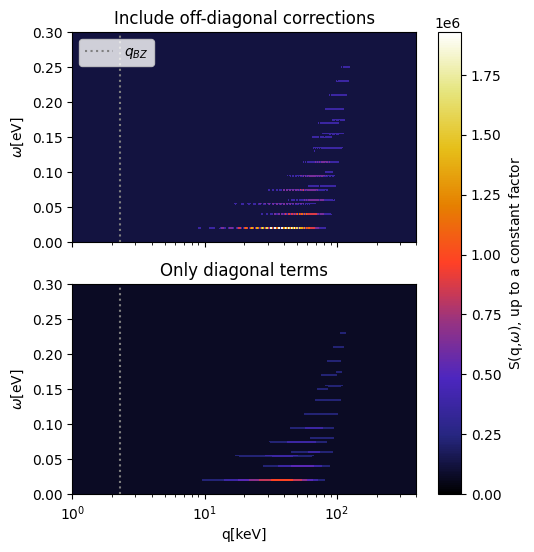

In [18]:
#Graphing the structure factor colorplot
X, Y = np.meshgrid(q_list,omega_list)
fig, axes = plt.subplots(nrows=2, figsize=(4,6),sharey=True,sharex=True)
cmap = matplotlib.colormaps.get_cmap('CMRmap')
normalizer = Normalize(0, np.max(s_list_plot))
im = cm.ScalarMappable(norm=normalizer, cmap='CMRmap')

axes[0].contourf(X, Y, s_list_plot,cmap='CMRmap',norm=normalizer)
axes[0].axvline(qbz/1000, linestyle=':', color='gray',label=r'$q_{BZ}$') #Brillouin zone in keV
axes[0].set_xscale('log')
axes[0].set_title('Include off-diagonal corrections')
axes[0].set_ylabel('$\omega$[eV]')
axes[0].legend(loc='upper left')


axes[1].contourf(X, Y, s_diag_list_plot,cmap='CMRmap', norm=normalizer)
axes[1].axvline(2*np.pi/(a_Si*1000), linestyle=':', color='gray')
axes[1].set_xscale('log')
axes[1].set_title('Only diagonal terms')
axes[1].set_xlabel('q[keV]')
axes[1].set_ylabel('$\omega$[eV]')

fig.subplots_adjust(right=1.2, wspace=0)
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label(r'S(q,$\omega$), up to a constant factor', )

plt.show()

# Differential Momentum Spectrum
We will now find the derivative of the scattering rate with respect to q.  The equation for the scattering rate is $$ R_\chi = \frac{\rho_\chi}{\rho_T m_\chi} \int \frac{dq \, q}{(2\pi)^2} \, \cdot \frac{\pi \sigma}{\mu_\chi^2} \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)$$ 

This makes the derivative with respect to q: $$\frac{\partial R}{\partial q} = \frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)=\frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \sum_n \sum_{j=0}^n \eta(v_{min}(q,\omega_{n,j})) \cdot S_{n,j}(q)$$

In [19]:
"""
This gives the two-body reduced mass equation
@params:
    m1, m2: masses of the two bodies
@returns: Effective mass of the two bodies
"""
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

First, we code the inverse mean function $\eta(v_{min})$

In [20]:
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))

"""
Helper function 1 and 2 for finding the output of the inverse mean function.
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const
def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const


"""
Returns the inverse mean value for any given v_min.  
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

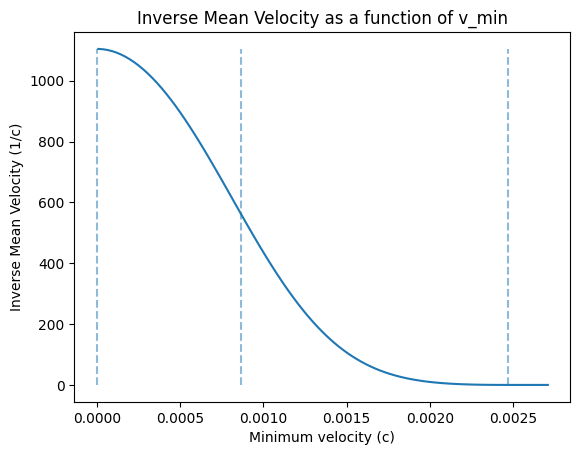

In [21]:
#Graphing the inverse mean as a function of the minimum velocity

vmin_range = np.linspace(0.01*v_E, v_esc+v_E*1.3, 100)
imf_mass = 50
imf_vmin = [inverseMeanFunction(v, imf_mass) for v in vmin_range]

plt.plot(vmin_range, imf_vmin)
plt.vlines([0, v_esc-v_E, v_esc+v_E], 0,max(imf_vmin), linestyles="dashed", alpha=0.5)
plt.title("Inverse Mean Velocity as a function of v_min")
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("Minimum velocity (c)")
plt.show()

In [22]:
"""
Find the minumum speed of dark matter
@params: 
    q: momentum transfer
    m_chi: mass of a dark matter particle
    w: energy transfer
@returns: minimum velocity of dark matter to hit crystal
"""
def v_min(q,m_chi, w): 
    return w/q+q/(2*m_chi)

Once we have the mean velocity equation, we can then find the derivative of the scattering rate with respect to q and integrate to find the scattering rate for one type of phonon

In [23]:
"""
This gives the derivative of the scattering rate with respect to the momentum transfer
@params:
    q: momentum transfer
    m_chi: mass of dark matter
    n: principle phonon number
    j: phonon mode number
    sigma: cross section
    A: coupling strength
    V: volume of the crystal
    a: lattice constant of the crystal
@returns:
    dR/dq
"""
def R_deriv_q_onePhonon(q, m_chi, n, j,sigma=1, A=f, V=a_Si, a=a_Si): 
    sFactor = StructureFactor_n_j(q,m_Si_nucleus, w_plus, w_minus, n, j, V, a, A)
    reducMass = reducedMass(m_chi, proton_mass)
    front_terms = dm_density*sigma/(4*np.pi*target_density*m_chi* reducMass**2)
    w_curr=n*w_minus+j*(w_plus-w_minus)
    return front_terms*q*inverseMeanFunction(v_min(q,m_chi, w_curr), m_chi)*sFactor*3.15576e7 *1000/(6.626e-60*4.1356**2)*(2*np.pi)**3

In [24]:
"""
This gives the derivative of the scattering rate with respect to the momentum transfer for the diagonal portion
@params:
    q: momentum transfer
    m_chi: mass of dark matter
    n: principle phonon number
    j: phonon mode number
    sigma: cross section
    A: coupling strength
    V: volume of the crystal
    a: lattice constant of the crystal
@returns:
    dR/dq
"""
def R_deriv_q_diag_n(q, m_chi, n,j, sigma=1, A=f, V=a_Si, a=a_Si): 
    sFactor= 2*A**2* diagonal_C_true(q, m_Si_nucleus, w_plus,w_minus, n, j, V)
    reducMass = reducedMass(m_chi, proton_mass)
    front_terms = dm_density*sigma/(4*np.pi*target_density*m_chi* reducMass**2)
    w_curr=n*w_minus+j*(w_plus-w_minus)
    return front_terms*q*inverseMeanFunction(v_min(q,m_chi, w_curr), m_chi)*sFactor*3.15576e7 *1000/(6.626e-60*4.1356**2)*(2*np.pi)**3

In [25]:
#Finds the derivative of the scattering rate with respect to momentum transfer
q_range = np.linspace(3,5.5,500)
q_range = 10**q_range

deriv = [[sum([R_deriv_q_onePhonon(q,40e6, n,j, sigma=1e-42, V=(a_Si**3)/4) for j in range(n+1)]) 
          for q in q_range] for n in range(1,11)]
deriv_diag = [[sum([R_deriv_q_diag_n(q, 40e6, n,j, sigma=1e-42, V=a_Si**3/4) for j in range(n+1)]
                               ) for q in q_range] for n in range(1,11)]

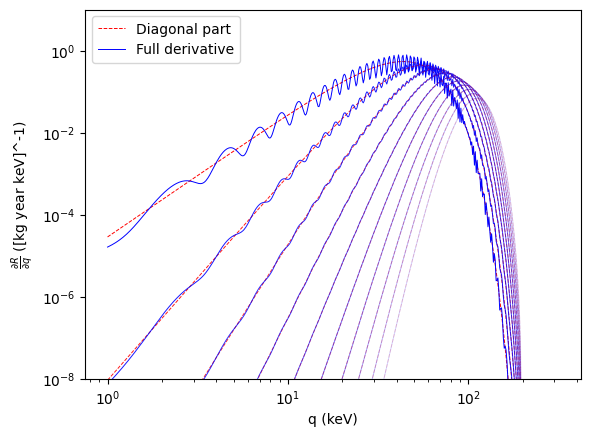

In [26]:
#Graphing the derivative
for i in range(10):
    plt.plot(q_range/1000, deriv_diag[i], color="red", alpha=(11-i)/11, linewidth=0.7, linestyle="dashed")
    plt.plot(q_range/1000, deriv[i], color="blue", alpha=(11-i)/11, linewidth=0.7)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(["Diagonal part", "Full derivative"])
plt.show()

In [99]:
"""
Sums up all dR/dq from a threshold energy to a high principal phonon number
@params: 
    q: momentum transfer
    m_chi: dark matter mass
    w_mini: minimum energy
    w_max: maximum energy
    sigma: cross-sectional area
    A: coupling constant
    V: volume of crystal
    a: lattice spacing
"""
def R_deriv_q_combo(q,m_chi, w_mini,w_max=0.1,sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    n_min = max(math.ceil(w_mini/w_minus), 1)
    n_max = int(w_max/w_plus)
    tot = sum(sum(R_deriv_q_onePhonon(q, m_chi, n, j, sigma, A, V, a) for j in range(min([int((n*w_minus-w_mini)/(w_minus-w_plus)),n])+1)) for n in range(n_min, n_max))
    return tot

In [151]:
"""
Sums up all dR/dq from a threshold energy to a high principal phonon number
@params: 
    q: momentum transfer
    m_chi: dark matter mass
    w_mini: minimum energy
    w_max: maximum energy
    sigma: cross-sectional area
    A: coupling constant
    V: volume of crystal
    a: lattice spacing
"""
def R_deriv_q_combo(q,m_chi, w_mini,w_max=0.1,sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    n_min = max(math.ceil(w_mini/w_minus), 1)
    n_max = int(w_max/w_plus)
    if n_min>n_max:
        return None
    tot = sum(sum(R_deriv_q_onePhonon(q, m_chi, n, j, sigma, A, V, a) 
                  for j in range(max([0, int((n*w_minus-w_max)/(w_minus-w_plus))]), min([math.ceil((n*w_minus-w_mini)/(w_minus-w_plus)),n])+1)) for n in range(n_min, n_max+1))
    return tot

In [124]:
ThomasFermi = 0.37 *a0
def Screening(q):
    return (ThomasFermi*q)**4/(1+(ThomasFermi*q)**2)**2
def R_q_func_screen(q, m_chi, w_mini,w_max, sigma, A, V, a):
    return R_deriv_q_combo(q,m_chi, w_mini,w_max, sigma, A, V, a) *Screening(q)

In [125]:
#creates and times the combined dR/dq
start = time.time()
deriv_combo = [R_deriv_q_combo(q, 40e6, 0,sigma=1e-42,w_max=1) for q in q_range]
print(time.time()-start)

2.1856441497802734


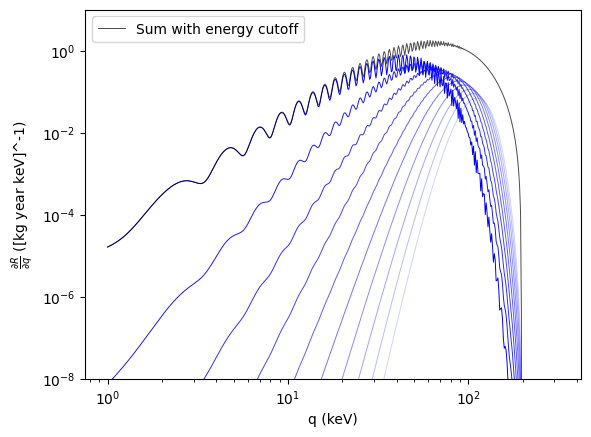

In [126]:
for i in range(10):
    plt.plot(q_range/1000, deriv[i], color="blue", alpha=(11-i)/11, linewidth=0.7)
plt.plot(q_range/1000, deriv_combo, color="black", alpha=0.7, linewidth=0.7, label="Sum with energy cutoff")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend()
plt.show()

In [127]:
Z=f
"""
R over q from 2011 paper
"""
def R_over_q_one_n(q,n, m_chi, N_T, sigma, w0=30e-3):
    q0 = np.sqrt(2*m_Si_nucleus*w0)
    reducedmass = reducedMass(m_chi, proton_mass) #in eV
    constants = N_T*dm_density/m_chi * Z**2*sigma/(2*reducedmass**2)
    inside_summation = (q/math.factorial(n)) 
    inside_summation*=(q/q0)**(2*n)*np.exp(-(q/q0)**2)*inverseMeanFunction(v_min(q,m_chi,n*w0),m_chi)
    return constants*inside_summation *2.998e10 *3.15576e7 *1000 #convertion to [kg year keV]^-1

def R_over_q_combo(q,m_chi, w_mini,N_T, sigma, w_max=0.1, w0=30e-3):
    n_min = max(int(w_mini/w0),1)
    n_max = int(w_max/w0)
    arr = []
    for n in range(n_min, n_max):
        arr.append(R_over_q_one_n(q,n, m_chi, N_T, sigma))
    return sum(arr)*Screening(q)

mX=40e6
NT = 6.022e23/(28.085e-3)
deriv2 = [[R_over_q_one_n(q,n,mX,NT, 1e-42, 30e-3) for q in q_range] for n in range(1,11)]

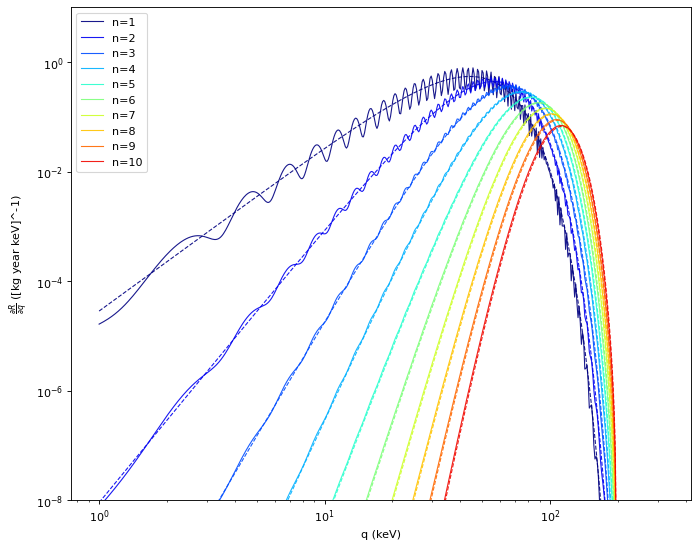

In [128]:
#Comparison of our dR/dq and the one from the 2011 paper
plt.figure(figsize=(10,8), dpi=80)
colors = plt.cm.jet(np.linspace(0,1,11))
for i in range(10):
    plt.plot(q_range/1000, deriv[i], color=colors[i], alpha=0.9, linewidth=1, label="n="+str(i+1))
    plt.plot(q_range/1000, deriv2[i], color=colors[i], alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(loc="upper left")
plt.show()

/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_25905/1605393365.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


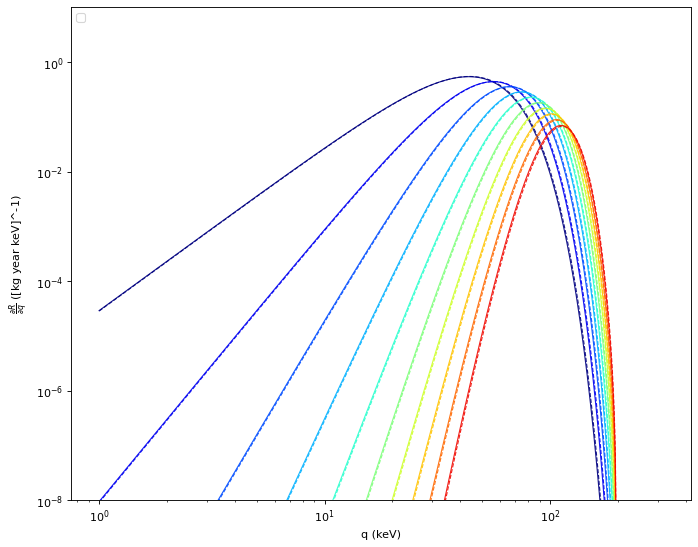

In [129]:
plt.figure(figsize=(10,8), dpi=80)
colors = plt.cm.jet(np.linspace(0,1,11))
for i in range(10):
    plt.plot(q_range/1000, deriv_diag[i], color=colors[i], alpha=0.9, linewidth=1)
    plt.plot(q_range/1000, deriv2[i], color=colors[i], alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(loc="upper left")
plt.show()

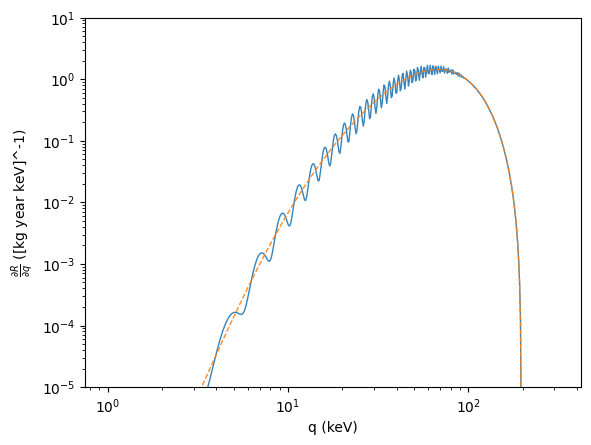

In [130]:
#Comparison of the total dR/dq
deriv_tot_2011 = [R_over_q_combo(q,mX, 30e-3,NT, 1e-42, w_max=1, w0=30e-3, ) for q in q_range]
plt.plot(q_range/1000, deriv_combo*Screening(q_range), alpha=0.9, linewidth=1)
plt.plot(q_range/1000, deriv_tot_2011, alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-5,10])
plt.show()

In [131]:
#Rough estimation of the scattering rates for both for parameters given in the 2011 paper
print(sum([deriv_combo[i]*(q_range[i]-q_range[i-1])*Screening(q_range[i]) for i in range(1,len(q_range))]))
print(sum([deriv_tot_2011[i]*(q_range[i]-q_range[i-1]) for i in range(1,len(q_range))]))

107294.76153923405
107280.16685178937


The inverse mean function is only nonzero when $v_{min}<v_{esc}+v_E$.  Plugging in $v_{min}=\frac{\omega}{q}+\frac{q}{2m_\chi}$ and solving the quadratic, we get the following boundary: $m_\chi(v_{esc}+v_E)-\sqrt{m_\chi^2(v_{esc}+v_E)^2-2m_\chi \omega}<q<m_\chi(v_{esc}+v_E)+\sqrt{m_\chi^2(v_{esc}+v_E)^2-2m_\chi \omega}$

The largest boundary occurs when the energy equals $\omega_+$

# Differential energy spectrum
How does the scattering rate depend on energy?

In [132]:
def dR_dw_n_j(w, m_chi, n,j, sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*w
    if root<=0:
        return None
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    integral = scipy.integrate.nquad(R_deriv_q_onePhonon, [bounds], args=(m_chi, n, j, sigma, A, V, a))[0]
    return integral

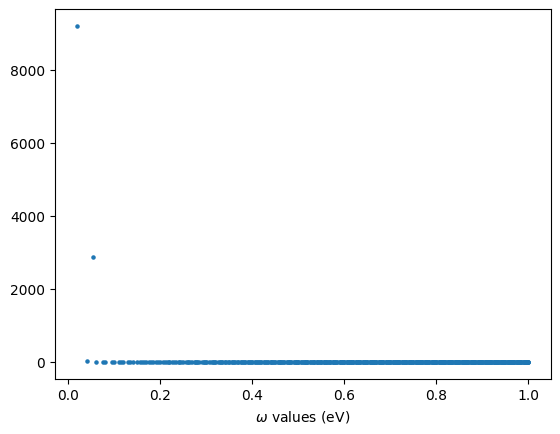

0.3321359157562256


In [185]:
mX=1e6
NT = 6.022e23/(28.085e-3)
starttime = time.time()
w_list =[]
w_max = 1
dR_dw_list = []
for n in range(1,int(w_max/w_plus)):
    for j in range(max([0, math.ceil((n*w_minus-w_max)/(w_minus-w_plus))]),n+1):
        w_current = j*w_plus+(n-j)*w_minus
        w_list.append(w_current)
        dR_dw_list.append(dR_dw_n_j(w_current, mX, n, j, 1e-42))
        if w_current>w_max:print(str(n)+" "+str(j)) #should not print anything
plt.scatter(w_list, dR_dw_list, s=5)
#plt.yscale("log")
plt.xlabel(r"$\omega$ values (eV)")
plt.show()
print(time.time()-starttime)   

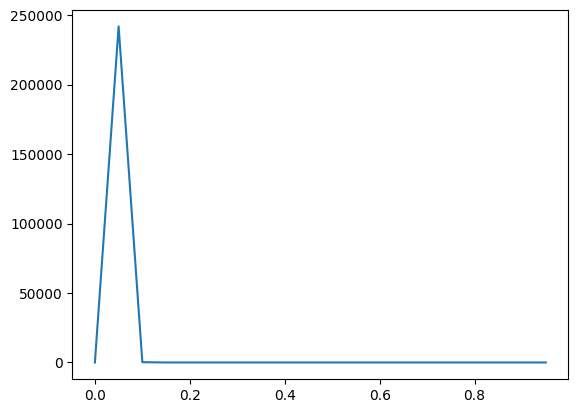

In [187]:
ordered = np.argsort(w_list)
w_list = np.array(w_list)[ordered]
dR_dw_list = np.array(dR_dw_list)[ordered]

stepsize=0.05
w_values = np.arange(0, 1, stepsize)
y = []
ind = 0

for w in w_values:
    height = 0
    while w_list[ind]<w+1/steps:
        if ind>len(w_list)-1:
            break
        height+=dR_dw_list[ind]
        ind+=1
    y.append(height/stepsize)
plt.plot(w_values, y)
#plt.yscale("log")
plt.show()

# Cross-section

In [137]:
"""
Gives the cross-sectional area necessary to get a certain rate
@params:
    R_q_func: the dR/dq function to be integrated
    params: the other parameters to input into R_q_func.  Mass of dark matter should be the first value
    wmin: the minimum energy of the system
    rate: scattering rate
"""
def cross_Sect(R_q_func, params, wmin,rate=3):
    m_chi = params[0]
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*wmin
    if root<=0:
        return None
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    integral = scipy.integrate.nquad(R_q_func, [bounds], args=params)[0]
    if integral==0:
        return None
    return rate/integral

In [138]:
#R_q_func_screen(q, m_chi, w_mini,w_max, sigma, A, V, a):
starttime = time.time()
mass_range = 10**np.linspace(5.5, 9.5, 100) #in eV
cr1 = [cross_Sect(R_q_func_screen, (m, 20e-3, 0.5, 1, f, (a_Si**3)/4, a_Si), 20e-3) for m in mass_range]
print(time.time()-starttime)

161.52014207839966


In [139]:
#R_over_q_combo(q,m_chi, w_mini,N_T, sigma, w_max=0.1, w0=30e-3):
starttime = time.time()
cr_2011 = [cross_Sect(R_over_q_combo, (m, 20e-3, NT,1, 0.5, 30e-3), 20e-3) for m in mass_range]
print(time.time()-starttime)

1.5859131813049316


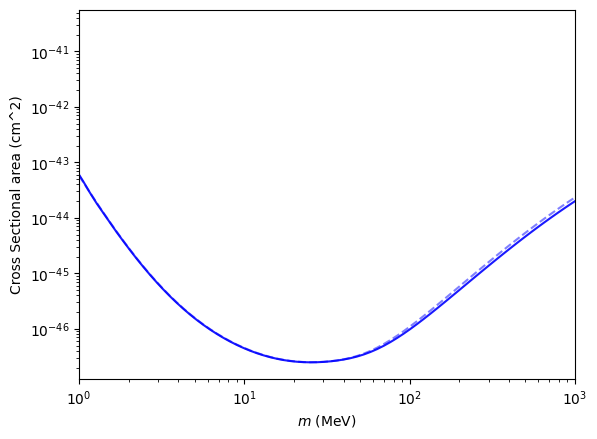

In [140]:
#Graph of our cross-section vs cross section from 2011 paper for a minimum energy of 20e-3
plt.plot(mass_range/1e6, cr1, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.xlim([1, 1e3])
plt.show()

In [141]:
#R_over_q_combo(q,m_chi, w_mini,N_T, sigma, w_max=0.1, w0=30e-3)
#R_q_func_screen(q, m_chi, w_mini,w_max, sigma, A, V, a)
starttime = time.time()
cr2_2011 = [cross_Sect(R_over_q_combo, (m, 60e-3, NT,1, 0.5, 30e-3), 60e-3) for m in mass_range]
cr2 = [cross_Sect(R_q_func_screen, (m, 60e-3, 0.5, 1, f, (a_Si**3)/4, a_Si), 60e-3) for m in mass_range]
print(time.time()-starttime)

154.58330607414246


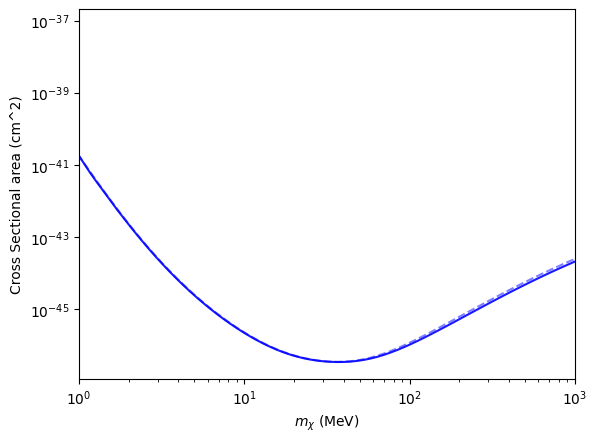

In [142]:
plt.plot(mass_range/1e6, cr2, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr2_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m_\chi$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.xlim([1, 1e3])
plt.show()

In [143]:
starttime = time.time()
cr3_2011 = [cross_Sect(R_over_q_combo, (m, 1, NT,1.2, 0.5, 30e-3), 1) for m in mass_range]
cr3 = [cross_Sect(R_q_func_screen, (m, 1, 1.2, 1, f, (a_Si**3)/4, a_Si), 1) for m in mass_range]
print(time.time()-starttime)

246.8863160610199


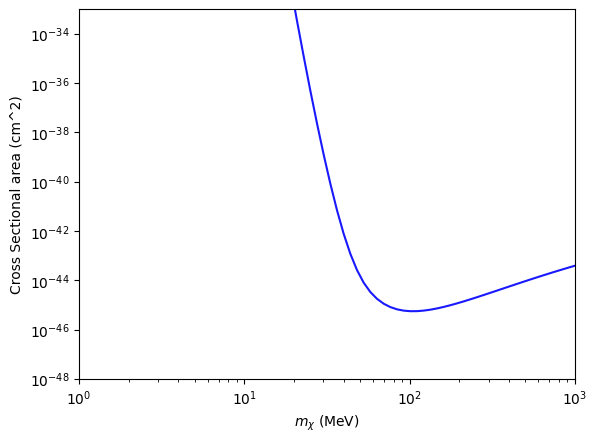

In [147]:
plt.plot(mass_range/1e6, cr3, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr3_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m_\chi$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.xlim([1, 1e3])
plt.ylim([1e-48, 1e-33])
plt.show()

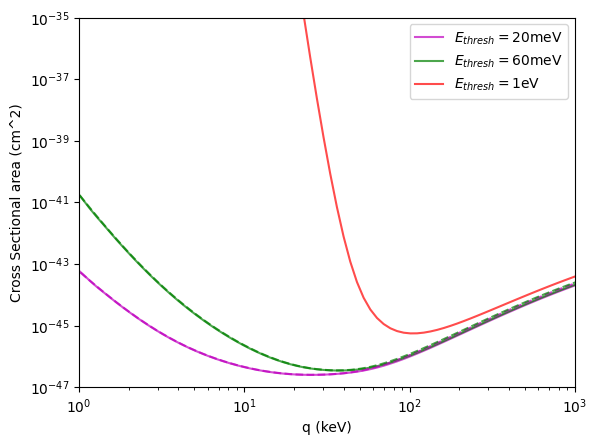

In [148]:
plt.plot(mass_range/1e6, cr1, color="m", alpha=0.7, label=r"$E_{thresh}=20$meV")
plt.plot(mass_range/1e6, cr2, color="g", alpha=0.7, label=r"$E_{thresh}=60$meV")
plt.plot(mass_range/1e6, cr3, color="r", alpha=0.7, label=r"$E_{thresh}=1$eV")

plt.plot(mass_range/1e6, cr_2011, color="m", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr2_2011, color="g", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr3_2011, color="r", alpha=0.7, linestyle="dashed")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Mass (keV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.xlim([1, 1e3])
plt.ylim([1e-47, 1e-35])
plt.legend()
plt.show()

In [152]:
#R_deriv_q_combo(q,m_chi, w_mini,w_max=0.1,sigma=1, A=f, V=(a_Si**3)/4, a=a_Si)
starttime = time.time()
cr1_noscreen = [cross_Sect(R_deriv_q_combo, (m, 20e-3, 0.5), 20e-3) for m in mass_range]
cr2_noscreen = [cross_Sect(R_deriv_q_combo, (m, 60e-3, 0.5), 60e-3) for m in mass_range]
cr3_noscreen = [cross_Sect(R_deriv_q_combo, (m, 1, 1.2, 1), 1) for m in mass_range]
print(time.time()-starttime)

1314.9354498386383


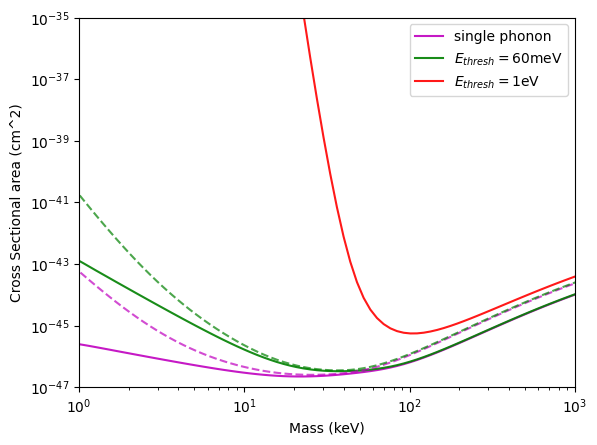

In [179]:
plt.plot(mass_range/1e6, cr1_noscreen, color="m", alpha=0.9, label="single phonon")
plt.plot(mass_range/1e6, cr2_noscreen, color="g", alpha=0.9, label=r"$E_{thresh}=60$meV")
plt.plot(mass_range/1e6, cr3_noscreen, color="r", alpha=0.9, label=r"$E_{thresh}=1$eV")

plt.plot(mass_range/1e6, cr_2011, color="m", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr2_2011, color="g", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr3_2011, color="r", alpha=0.7, linestyle="dashed")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Mass (keV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.xlim([1, 1e3])
plt.ylim([1e-47, 1e-35])
plt.legend()
plt.show()

In [44]:
def cross_section(m_chi, w_mini, top=20, rate=3):
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*w_mini
    if root<0:
        return None
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    integral = scipy.integrate.nquad(R_deriv_q_combo, [bounds], args=(m_chi, w_mini, 1))[0]
    if integral==0:
        return None
    return rate/integral

# Class Creation

In [ ]:
class TwoSiteScattering:
    def __init__(self, m_chi, cross_section, A, V, w1, w2, m_targ, lattice_spacing):
        self.mX = m_chi
        self.sig = cross_section
        self.A = A
        self.V = V
        self.w1 = w1
        self.w2 = w2
        self.m_targ = m_targ
        self.a=lattice_spacing

    """
    The Debye-Waller function for a two-site lattice
    @params 
        q: the momentum transfer from dark matter to the crystal
        m: mass of nucleus in the crystal
        w1, w2: energy levels of the element
    """
    def debye_waller(self, q):
        return q**2/(8*self.m_targ)*(1/self.w1+1/self.w2)
    
    
    """
    The diagonal terms (without the delta function) for one n,j combination
    @params
        q: the momentum transfer from dark matter to the crystal
        m: mass of nucleus in the crystal
        w1, w2: energy levels of the element
        n: principle phonon number
        j: phonon mode number
        V: 1D volume (ie length) of target crystal
    """
    def diagonal_C_true(self, q, n, j):
        expDebyeWaller = np.exp(-2*self.debye_waller(q))
        c=expDebyeWaller/self.V * (q**2/(4*self.m_targ))**n * 2*np.pi/(factorial(j)*factorial(n-j)*self.w1**j*self.w2**(n-j))
        return c
    
    """
    The off-diagonal terms (without the delta function) for one n,j combination
    @params
        q: the momentum transfer from dark matter to the crystal
        m: mass of nucleus in the crystal
        w1, w2: energy levels of the element
        n: principle phonon number
        j: phonon mode number
        V: 1D volume (ie length) of target crystal
        a: the lattice constant of the crystal
    """
    def offDiagonal_C_true(self, q, n, j):
        expDebyeWaller = np.exp(-2*debye_waller(q, self.m_targ, self.w1, self.w2))
        c=expDebyeWaller/self.V * (q**2/(4*self.m_targ))**n * 2*np.pi/(factorial(j)*factorial(n-j)*self.w1**j*self.w2**(n-j))
        if (n-j)%2==1:
            c = -c
        c = c*np.cos(q*a)
        return c

    """
    Structure Factor for one n and j pair, integrated with omega to remove the delta function
    @params
        q: the momentum transfer from dark matter to the crystal
        m: mass of nucleus in the crystal
        w1, w2: energy levels of the element
        n: principle phonon number
        j: phonon mode number
        V: 1D volume (ie length) of target crystal
        a: the lattice constant of the crystal
        A: coupling strength
    """
    def StructureFactor_n_j(q,n, j):
        return 2*self.A**2*(diagonal_C_true(q, n, j)
                          +offDiagonal_C_true(q, n, j))
    
    